# Calculate the energy-based SOH


In [8]:
import os
import sys
import math
sys.path.append(os.path.join(os.getcwd().partition('EV_DVA_Robustness')[0], "EV_DVA_Robustness"))
from src.config_base import GeneralConfig

In [9]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator, FixedLocator

In [10]:
from src.data.read_feather import ReadFeather
from src.filtering.filter_methods import FilterMethods
from src.voltage_capacity_analysis.ica import ICA
from src.voltage_capacity_analysis.dva import DVA
from src.visualization.config_visualization import VisualizationConfig, instantiate_matplotlib_parameters, cm2inch
instantiate_matplotlib_parameters()
from src.visualization.colormaps import ColorMaps

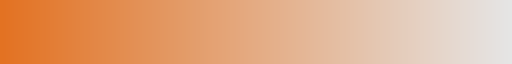

In [11]:
tum_orange_cmap = ColorMaps.orange_tum()
orange_colors = tum_orange_cmap(np.linspace(0,1, 6))
tum_orange_cmap

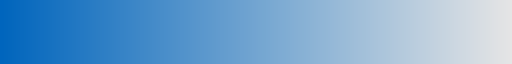

In [12]:
tum_blue_cmap = ColorMaps.blue_tum()
blue_colors = tum_blue_cmap(np.linspace(0,1, 6))
tum_blue_cmap

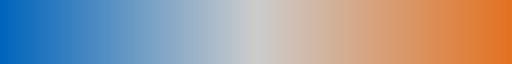

In [13]:
tum_cmap = ColorMaps.blue_orange_tum(grayscale=0.8)
colors = tum_cmap(np.linspace(0,1,5))
tum_cmap

In [14]:
def filter_func_preprocess_U(signal):
    perc_filter = 1/100 * len(signal) #% filter
    filtered_signal = FilterMethods().rolling_mean_df(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter))
    #filtered_signal = FilterMethods().savgol(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    return filtered_signal

In [15]:
def filter_func_preprocess_Q(signal):
    perc_filter = 1/100 * len(signal) #% filter
    filtered_signal = FilterMethods().rolling_mean_df(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter))
    #filtered_signal = FilterMethods().savgol(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    return filtered_signal

In [16]:
read_feather = ReadFeather()
#read_feather.set_filter_U(filter_func_preprocess_U)
read_feather.set_filter_Q(filter_func_preprocess_Q)

In [17]:
E_nom_VW = 58
E_nom_TM3 = 52.5

## C-Rate

In [33]:
%%capture
df_vw_288_C45 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_JB_8A_CEE7_C45.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) # eval was started 2V below so that the steep flank in DVA is not filtered out
df_vw_288_C17 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_JB_6A_CEE16_C17.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_288_C10 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_JB_10A_CEE16_C10.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_288_C6 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_JB_32A_CEE32_C6.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 

In [35]:
%%capture
df_tesla_C57 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Tesla","Tesla_JB_6A_CEE7_C57_2022_w_cv.feather"), calc_E = True, lower_voltage=340, upper_voltage=380) 
df_tesla_C17 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Tesla","Tesla_AC_5A_C17_w_cv.feather"), calc_E = True, lower_voltage=340, upper_voltage=380) 
df_tesla_C10 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Tesla","Tesla_AC_8A_C10_w_cv.feather"), calc_E = True, lower_voltage=340, upper_voltage=380) 
df_tesla_C8= read_feather.read(os.path.join(GeneralConfig.path2data.value,"Tesla","Tesla_AC_10A_C8_w_cv.feather"), calc_E = True, lower_voltage=340, upper_voltage=380) 
df_tesla_C5= read_feather.read(os.path.join(GeneralConfig.path2data.value,"Tesla","Tesla_AC_16A_C5_w_cv.feather"), calc_E = True, lower_voltage=340, upper_voltage=380) 

## Temperature

In [37]:
%%capture
df_vw_288_outside = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_JB_6A_CEE16_C17_outside.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 

In [38]:
%%capture
df_tesla_C13_outside= read_feather.read(os.path.join(GeneralConfig.path2data.value,"Tesla","Tesla_JB_6A_CEE16_C13_outside_w_cv.feather"), calc_E = True, lower_voltage=340, upper_voltage=380 ) 

## Roundtrip

In [39]:
%%capture
df_vw_288_discharge = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_C10_discharge.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_288_discharge["E"] = np.abs(sp.integrate.cumtrapz(df_vw_288_discharge["P"]/1000, df_vw_288_discharge["time_h"], initial=0))
df_vw_288_discharge["Q"] = np.abs(sp.integrate.cumtrapz(df_vw_288_discharge["I"], df_vw_288_discharge["time_h"], initial=0))

## Relaxation

In [41]:
%%capture
df_vw_pre = read_feather.read(os.path.join(GeneralConfig.path2data.value,"VW","VW_ID3_FTM_JB_8A_CEE7_preRelax.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_mid = read_feather.read(os.path.join(GeneralConfig.path2data.value,"VW","VW_ID3_FTM_8A_CEE7_RelaxHighSOC.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_post= read_feather.read(os.path.join(GeneralConfig.path2data.value,"VW","VW_ID3_FTM_8A_CEE7_RelaxLowSOC.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 

## Repeatability

In [42]:
%%capture
df_vw_213 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_213_JB_8A_CEE7_C45.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_213_rep2 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_213_JB_8A_CEE7_C45_repeatability.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_213_rep3 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_213_JB_8A_CEE7_C45_repeatability_2.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 

## Comparability

In [43]:
%%capture
df_vw_204 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_204_JB_8A_CEE7_C45.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_288 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_JB_8A_CEE7_C45.feather"), calc_E = True, lower_voltage=370, upper_voltage=450)
df_vw_349 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_349_JB_8A_CEE7_C45.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_397 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_397_JB_8A_CEE7_C45.feather"), calc_E = True, lower_voltage=370, upper_voltage=450)

## Plot

In [44]:
def bar_plot_soh(axes, X,y1,title = "",first_plot=True,lst_colors=orange_colors,remove_tick_ind=None):
    
    axes.spines['top'].set_color('white')
    axes.spines['left'].set_color('white')
    axes.spines['right'].set_color('white')
    
    width = 0.45 # the width of the bars      
    x = np.arange(len(X))*width 
    axes.set_xlim([-width,np.max(x)+width])
    for bar in range(len(x)):
        rects = axes.bar(x[bar], y1[bar], width,color=lst_colors[bar],edgecolor="k")
    #axes.bar_label(rects, padding=-50,rotation=90,fontsize=9,color="white")
    for label,pos in zip(y1,x):
        if label>0:
            label = round(label,1)
            axes.annotate(text=str(label)+" %",
                          xy=(pos+0.05,label-1),
                          horizontalalignment="center",
                          verticalalignment="top",
                          fontsize=7,color="w",rotation=90,)
                          #bbox=dict(boxstyle='square,pad=.0',fc='white', ec='white', alpha=0.75))
                        
    axes.set_xticks(x)
    tick_labels = [label for label in X]
    axes.set_xticklabels(tick_labels,rotation=45,fontsize=9,ha='right',va="top",rotation_mode="anchor")
    

    axes.set_ylim([70,110])
    tick_positions = np.array([70,80,90,100])
    axes.set_yticks(tick_positions)
    #axes.yaxis.set_minor_locator(FixedLocator([75,85,95,105]))
    axes.tick_params(axis='y', colors='black',length=0)
    axes.grid(axis='y')
    axes.set_axisbelow(True)
    axes.tick_params('y', left=True, labelleft=False,right=False, labelright=False)
    axes.set_title(title,fontsize=9, y=0.8)
    if first_plot:
        axes.set_ylabel(r"$SOH_E$ in %",fontsize=9)
        axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)

    if remove_tick_ind:
        #remove specific tick
        axes.xaxis.get_major_ticks()[remove_tick_ind].draw = lambda *args:None
    return axes

In [45]:
tum_orange_cmap = ColorMaps.orange_tum()
orange_colors_crate = tum_orange_cmap(np.linspace(0,1, 5))

In [46]:
tum_blue_cmap = ColorMaps.blue_tum()
blue_colors_crate = tum_blue_cmap(np.linspace(0,1,5))

In [47]:
tum_cmap = ColorMaps.blue_orange_tum(grayscale=0.5)
o_b_colors_max = tum_cmap(np.linspace(1,0, 2))

In [48]:
tum_cmap = ColorMaps.blue_orange_tum(grayscale=0.6)
o_b_colors_rep = tum_cmap(np.linspace(1,0, 3))

In [49]:
tum_cmap = ColorMaps.blue_orange_tum(grayscale=0.6)
o_b_colors_comp = tum_cmap(np.linspace(1,0, 5))

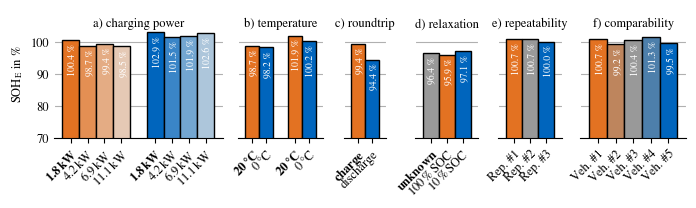

In [51]:
gridspec = dict(hspace=0, width_ratios=[8,4,2,3,3,5])

heigth = 5
fig,axes= plt.subplots(1,6,figsize=(VisualizationConfig.textwidth_in_in.value,
                                cm2inch(heigth)),gridspec_kw=gridspec,constrained_layout=True)

axes = axes.flatten()

# C-rate
names = [r"$\bf{1.8\, kW}$", "$4.2\, kW$", "$6.9\, kW$", "$11.1\, kW$",
         " ",   
        r"$\bf{1.8\, kW}$", "$4.2\, kW$", "$6.9\, kW$", "$11.1\, kW$"]
SOH_E_1 = np.hstack((np.array([df_vw_288_C45.E.max(),df_vw_288_C17.E.max(),df_vw_288_C10.E.max(),df_vw_288_C6.E.max()])/E_nom_VW*100,np.array([0]),
                     np.array([df_tesla_C57.E.max(),df_tesla_C17.E.max(),df_tesla_C10.E.max(),df_tesla_C5.E.max()])/E_nom_TM3*100))
axes[0] = bar_plot_soh(axes[0], names,SOH_E_1,title = "a) charging power",first_plot=True,lst_colors=np.vstack((orange_colors_crate,blue_colors_crate)),remove_tick_ind=4)


# temperature
names = [r"$\bf{20\, °C}$","$0\, °C$"," ",r"$\bf{20\, °C}$","$0\, °C$"]
SOH_E_1 = np.hstack((np.array([df_vw_288_C17.E.max(),df_vw_288_outside.E.max()])/E_nom_VW*100, np.array([0]),
                    np.array([df_tesla_C10.E.max(),df_tesla_C13_outside.E.max()])/E_nom_TM3*100))
axes[1] = bar_plot_soh(axes[1], names,SOH_E_1,title = "b) temperature",first_plot=False,lst_colors=np.vstack((o_b_colors_max,np.array([[0,0,0,1]]),o_b_colors_max)),remove_tick_ind=2)


# roundtrip
names = [r"$\bf{charge}$","discharge"]
SOH_E_1 = np.array([df_vw_288_C10.E.max(),df_vw_288_discharge.E.abs().max()])/E_nom_VW*100
axes[2] = bar_plot_soh(axes[2], names,SOH_E_1,title = "c) roundtrip",first_plot=False,lst_colors=o_b_colors_max)

# relaxation
names = [r"$\bf{unknown}$","$100\, \% \, SOC$","$10\, \% \, SOC$"]
SOH_E_1 = np.array([df_vw_pre.E.max(),df_vw_mid.E.abs().max(),df_vw_post.E.max()])/E_nom_VW*100
axes[3] = bar_plot_soh(axes[3], names,SOH_E_1,title = "d) relaxation",first_plot=False,lst_colors=o_b_colors_rep[[1,0,2]])

# repeatability
names = ["Rep. #1", "Rep. #2", "Rep. #3"]
SOH_E_1 = np.array([df_vw_213.E.max(),df_vw_213_rep2.E.abs().max(),df_vw_213_rep3.E.max()])/E_nom_VW*100
axes[4] = bar_plot_soh(axes[4], names,SOH_E_1,title = "e) repeatability",first_plot=False,lst_colors=o_b_colors_rep)

# comparability
names = ["Veh. #1", "Veh. #2", "Veh. #3", "Veh. #4", "Veh. #5"]
SOH_E_1 = np.array([df_vw_213.E.max(),df_vw_204.E.abs().max(),df_vw_288.E.max(),df_vw_349.E.max(),df_vw_397.E.max()])/E_nom_VW*100
axes[5] = bar_plot_soh(axes[5], names,SOH_E_1,title = "f) comparability",first_plot=False,lst_colors=o_b_colors_comp)

# # legend
# handles, labels = plt.gca().get_legend_handles_labels()  
# line = Patch(label='Cell', facecolor=VisualizationConfig.TUMgrau50.value)
# line2 = Patch(label='Reproducibility', facecolor=VisualizationConfig.TUMorange.value)
# line3 = Patch(label='Aging', facecolor=VisualizationConfig.TUMhellblau.value)
# line4 = Patch(label=r'$SOH_{E}$', facecolor=VisualizationConfig.TUMgrau50.value)
# line5 = Patch(label=r'$SOH_{C}$', facecolor=VisualizationConfig.TUMgrau50.value,alpha=0.7,hatch="////")
# # add manual symbols to auto legend
# handles.extend([line, line2, line3,line4, line5])
# plt.legend(handles=handles,loc="lower left",fontsize=9,ncols=2,
#            framealpha =1 , fancybox=False,labelspacing=0.2,columnspacing=0.8,edgecolor="black")

#plt.tight_layout()

fig.savefig(os.path.join(GeneralConfig.path2figures.value,"08-FIG-SOH_E.pdf"))
fig.savefig(os.path.join(GeneralConfig.path2figures.value,"08-FIG-SOH_E.png"),dpi=300)

In [52]:
def bar_plot_energy(axes, X,y1,title = "",first_plot=True,lst_colors=orange_colors,remove_tick_ind=None):
    
    axes.spines['top'].set_color('white')
    axes.spines['left'].set_color('white')
    axes.spines['right'].set_color('white')
    
    width = 0.45 # the width of the bars      
    x = np.arange(len(X))*width 
    axes.set_xlim([-width,np.max(x)+width])
    for bar in range(len(x)):
        rects = axes.bar(x[bar], y1[bar], width,color=lst_colors[bar],edgecolor="k")
    #axes.bar_label(rects, padding=-50,rotation=90,fontsize=9,color="white")
    for label,pos in zip(y1,x):
        if label>0:
            label = round(label,1)
            axes.annotate(text=str(label)+" kWh",
                          xy=(pos+0.05,label-1),
                          horizontalalignment="center",
                          verticalalignment="top",
                          fontsize=7,color="w",rotation=90,)
                          #bbox=dict(boxstyle='square,pad=.0',fc='white', ec='white', alpha=0.75))
                        
    axes.set_xticks(x)
    tick_labels = [label for label in X]
    axes.set_xticklabels(tick_labels,rotation=45,fontsize=9,ha='right',va="top",rotation_mode="anchor")
    

    axes.set_ylim([0,70])
    tick_positions = np.array([0,20,40,60])
    axes.set_yticks(tick_positions)
    #axes.yaxis.set_minor_locator(FixedLocator([75,85,95,105]))
    axes.tick_params(axis='y', colors='black',length=0)
    axes.grid(axis='y')
    axes.set_axisbelow(True)
    axes.tick_params('y', left=True, labelleft=False,right=False, labelright=False)
    axes.set_title(title,fontsize=9, y=0.8)
    if first_plot:
        axes.set_ylabel(r"Energy in kWh",fontsize=9)
        axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)

    if remove_tick_ind:
        #remove specific tick
        axes.xaxis.get_major_ticks()[remove_tick_ind].draw = lambda *args:None
    return axes

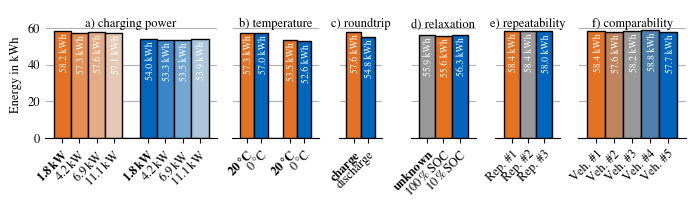

In [53]:
gridspec = dict(hspace=0, width_ratios=[8,4,2,3,3,5])

heigth = 5
fig,axes= plt.subplots(1,6,figsize=(VisualizationConfig.textwidth_in_in.value,
                                cm2inch(heigth)),gridspec_kw=gridspec,constrained_layout=True)

axes = axes.flatten()

# C-rate
names = [r"$\bf{1.8\, kW}$", "$4.2\, kW$", "$6.9\, kW$", "$11.1\, kW$",
         " ",   
        r"$\bf{1.8\, kW}$", "$4.2\, kW$", "$6.9\, kW$", "$11.1\, kW$"]
SOH_E_1 = np.hstack((np.array([df_vw_288_C45.E.max(),df_vw_288_C17.E.max(),df_vw_288_C10.E.max(),df_vw_288_C6.E.max()]),np.array([0]),
                     np.array([df_tesla_C57.E.max(),df_tesla_C17.E.max(),df_tesla_C10.E.max(),df_tesla_C5.E.max()])))
axes[0] = bar_plot_energy(axes[0], names,SOH_E_1,title = "a) charging power",first_plot=True,lst_colors=np.vstack((orange_colors_crate,blue_colors_crate)),remove_tick_ind=4)


# temperature
names = [r"$\bf{20\, °C}$","$0\, °C$"," ",r"$\bf{20\, °C}$","$0\, °C$"]
SOH_E_1 = np.hstack((np.array([df_vw_288_C17.E.max(),df_vw_288_outside.E.max()]), np.array([0]),
                    np.array([df_tesla_C10.E.max(),df_tesla_C13_outside.E.max()])))
axes[1] = bar_plot_energy(axes[1], names,SOH_E_1,title = "b) temperature",first_plot=False,lst_colors=np.vstack((o_b_colors_max,np.array([[0,0,0,1]]),o_b_colors_max)),remove_tick_ind=2)


# roundtrip
names = [r"$\bf{charge}$","discharge"]
SOH_E_1 = np.array([df_vw_288_C10.E.max(),df_vw_288_discharge.E.abs().max()])
axes[2] = bar_plot_energy(axes[2], names,SOH_E_1,title = "c) roundtrip",first_plot=False,lst_colors=o_b_colors_max)

# relaxation
names = [r"$\bf{unknown}$","$100\, \% \, SOC$","$10\, \% \, SOC$"]
SOH_E_1 = np.array([df_vw_pre.E.max(),df_vw_mid.E.abs().max(),df_vw_post.E.max()])
axes[3] = bar_plot_energy(axes[3], names,SOH_E_1,title = "d) relaxation",first_plot=False,lst_colors=o_b_colors_rep[[1,0,2]])

# repeatability
names = ["Rep. #1", "Rep. #2", "Rep. #3"]
SOH_E_1 = np.array([df_vw_213.E.max(),df_vw_213_rep2.E.abs().max(),df_vw_213_rep3.E.max()])
axes[4] = bar_plot_energy(axes[4], names,SOH_E_1,title = "e) repeatability",first_plot=False,lst_colors=o_b_colors_rep)

# comparability
names = ["Veh. #1", "Veh. #2", "Veh. #3", "Veh. #4", "Veh. #5"]
SOH_E_1 = np.array([df_vw_213.E.max(),df_vw_204.E.abs().max(),df_vw_288.E.max(),df_vw_349.E.max(),df_vw_397.E.max()])
axes[5] = bar_plot_energy(axes[5], names,SOH_E_1,title = "f) comparability",first_plot=False,lst_colors=o_b_colors_comp)


In [ ]:
def bar_plot_capacity(axes, X,y1,title = "",first_plot=True,lst_colors=orange_colors,remove_tick_ind=None):
    
    axes.spines['top'].set_color('white')
    axes.spines['left'].set_color('white')
    axes.spines['right'].set_color('white')
    
    width = 0.45 # the width of the bars      
    x = np.arange(len(X))*width 
    axes.set_xlim([-width,np.max(x)+width])
    for bar in range(len(x)):
        rects = axes.bar(x[bar], y1[bar], width,color=lst_colors[bar],edgecolor="k")
    #axes.bar_label(rects, padding=-50,rotation=90,fontsize=9,color="white")
    for label,pos in zip(y1,x):
        if label>0:
            label = round(label,1)
            axes.annotate(text=str(label)+" Ah",
                          xy=(pos+0.05,label-1),
                          horizontalalignment="center",
                          verticalalignment="top",
                          fontsize=7,color="k",rotation=90,)
                          #bbox=dict(boxstyle='square,pad=.0',fc='white', ec='white', alpha=0.75))
                        
    axes.set_xticks(x)
    tick_labels = [label for label in X]
    axes.set_xticklabels(tick_labels,rotation=45,fontsize=9,ha='right',va="top",rotation_mode="anchor")
    

    axes.set_ylim([0,200])
    tick_positions = np.array([0,50,100,150])
    axes.set_yticks(tick_positions)
    #axes.yaxis.set_minor_locator(FixedLocator([75,85,95,105]))
    axes.tick_params(axis='y', colors='black',length=0)
    axes.grid(axis='y')
    axes.set_axisbelow(True)
    axes.tick_params('y', left=True, labelleft=False,right=False, labelright=False)
    axes.set_title(title,fontsize=9, y=0.8)
    if first_plot:
        axes.set_ylabel(r"Capacity in Ah",fontsize=9)
        axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)

    if remove_tick_ind:
        #remove specific tick
        axes.xaxis.get_major_ticks()[remove_tick_ind].draw = lambda *args:None
    return axes

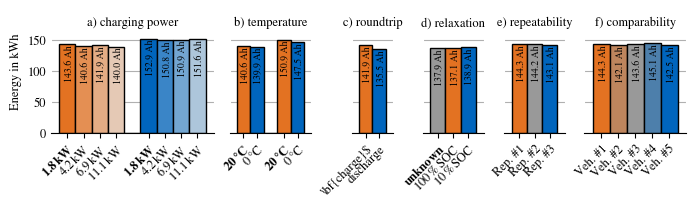

In [55]:
gridspec = dict(hspace=0, width_ratios=[8,4,2,3,3,5])

heigth = 5
fig,axes= plt.subplots(1,6,figsize=(VisualizationConfig.textwidth_in_in.value,
                                cm2inch(heigth)),gridspec_kw=gridspec,constrained_layout=True)

axes = axes.flatten()

# C-rate
names = [r"$\bf{1.8\, kW}$", "$4.2\, kW$", "$6.9\, kW$", "$11.1\, kW$",
         " ",   
        r"$\bf{1.8\, kW}$", "$4.2\, kW$", "$6.9\, kW$", "$11.1\, kW$"]
SOH_E_1 = np.hstack((np.array([df_vw_288_C45.Q.max(),df_vw_288_C17.Q.max(),df_vw_288_C10.Q.max(),df_vw_288_C6.Q.max()]),np.array([0]),
                     np.array([df_tesla_C57.Q.max(),df_tesla_C17.Q.max(),df_tesla_C10.Q.max(),df_tesla_C5.Q.max()])))
axes[0] = bar_plot_capacity(axes[0], names,SOH_E_1,title = "a) charging power",first_plot=True,lst_colors=np.vstack((orange_colors_crate,blue_colors_crate)),remove_tick_ind=4)


# temperature
names = [r"$\bf{20\, °C}$","$0\, °C$"," ",r"$\bf{20\, °C}$","$0\, °C$"]
SOH_E_1 = np.hstack((np.array([df_vw_288_C17.Q.max(),df_vw_288_outside.Q.max()]), np.array([0]),
                    np.array([df_tesla_C10.Q.max(),df_tesla_C13_outside.Q.max()])))
axes[1] = bar_plot_capacity(axes[1], names,SOH_E_1,title = "b) temperature",first_plot=False,lst_colors=np.vstack((o_b_colors_max,np.array([[0,0,0,1]]),o_b_colors_max)),remove_tick_ind=2)


# roundtrip
names = [r"\bf{charge}$","discharge"]
SOH_E_1 = np.array([df_vw_288_C10.Q.max(),df_vw_288_discharge.Q.abs().max()])
axes[2] = bar_plot_capacity(axes[2], names,SOH_E_1,title = "c) roundtrip",first_plot=False,lst_colors=o_b_colors_max)

# relaxation
names = [r"$\bf{unknown}$","$100\, \% \, SOC$","$10\, \% \, SOC$"]
SOH_E_1 = np.array([df_vw_pre.Q.max(),df_vw_mid.Q.abs().max(),df_vw_post.Q.max()])
axes[3] = bar_plot_capacity(axes[3], names,SOH_E_1,title = "d) relaxation",first_plot=False,lst_colors=o_b_colors_rep[[1,0,2]])

# repeatability
names = ["Rep. #1", "Rep. #2", "Rep. #3"]
SOH_E_1 = np.array([df_vw_213.Q.max(),df_vw_213_rep2.Q.abs().max(),df_vw_213_rep3.Q.max()])
axes[4] = bar_plot_capacity(axes[4], names,SOH_E_1,title = "e) repeatability",first_plot=False,lst_colors=o_b_colors_rep)

# comparability
names = ["Veh. #1", "Veh. #2", "Veh. #3", "Veh. #4", "Veh. #5"]
SOH_E_1 = np.array([df_vw_213.Q.max(),df_vw_204.Q.abs().max(),df_vw_288.Q.max(),df_vw_349.Q.max(),df_vw_397.Q.max()])
axes[5] = bar_plot_capacity(axes[5], names,SOH_E_1,title = "f) comparability",first_plot=False,lst_colors=o_b_colors_comp)
